In [ ]:
import polars as pl
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt


In [128]:
# ====== Previous File Format with full orderbook levels before preprocessing ========
# file_name = "btc-updown-15m-1771197300_orderbook"
# file_path = Path(f"data/external/polymarket/orderbooks/{file_name}.csv")
# ORIGINAL_ORDERBOOK_SCHEMA = {
#     "datetime_utc": pl.Datetime(time_zone="UTC"),
#     "market_slug": pl.Utf8,
#     "resolution": pl.Utf8,
#     "type": pl.Utf8,
#     "price": pl.Float64,
#     "size": pl.Float64,
#     "token_id": pl.Utf8,
# }
# df = pl.read_csv(file_path, schema=ORIGINAL_ORDERBOOK_SCHEMA)


# Preprocessed orderbook with only best bid/ask and imbalance features

file_name = "btc-updown-15m-1771218900_orderbook"
file_path = Path(f"data/external/polymarket/orderbooks/{file_name}.csv")

preprocessed_orderbook = pl.read_csv(file_path)
preprocessed_orderbook

datetime_utc,up_best_ask_price,up_best_ask_size,up_top3_ask_size,up_top5_ask_size,up_top10_ask_size,up_total_ask_size,up_ask_levels,up_ask_size_std,up_ask_max_single_size,up_best_bid_price,up_best_bid_size,up_top3_bid_size,up_top5_bid_size,up_top10_bid_size,up_total_bid_size,up_bid_levels,up_bid_size_std,up_bid_max_single_size,down_best_ask_price,down_best_ask_size,down_top3_ask_size,down_top5_ask_size,down_top10_ask_size,down_total_ask_size,down_ask_levels,down_ask_size_std,down_ask_max_single_size,down_best_bid_price,down_best_bid_size,down_top3_bid_size,down_top5_bid_size,down_top10_bid_size,down_total_bid_size,down_bid_levels,down_bid_size_std,down_bid_max_single_size,up_ask_vwap,up_bid_vwap,down_ask_vwap,down_bid_vwap,up_spread,down_spread,up_mid,down_mid,up_spread_pct,down_spread_pct,up_tob_imbalance,down_tob_imbalance,up_top5_imbalance,down_top5_imbalance,up_book_imbalance,down_book_imbalance,up_weighted_mid,down_weighted_mid,up_bid_tob_concentration,up_ask_tob_concentration,down_bid_tob_concentration,down_ask_tob_concentration,overround,spread_differential,tob_imbalance_differential,book_imbalance_differential,up_mid_skew,down_mid_skew
str,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2026-02-16T05:15:00.317779+000…",0.53,127.62,403.27,620.27,850.11,51902.91,42,4586.433316,28207.72,0.52,299.01,826.0,967.43,2053.51,53677.24,43,4575.915553,28659.72,null,null,0.0,0.0,0.0,0.0,0,null,null,null,null,0.0,0.0,0.0,0.0,0,null,null,0.959642,0.055432,NaN,NaN,0.01,null,0.525,null,0.019048,null,0.40173,null,0.218656,NaN,0.016806,NaN,0.527009,null,0.005571,0.002459,null,null,null,null,null,NaN,0.002009,null
"""2026-02-16T05:15:00.318379+000…",0.53,127.62,403.27,620.27,850.11,51902.91,42,4586.433316,28207.72,0.52,299.01,826.0,967.43,2053.51,53677.24,43,4575.915553,28659.72,0.48,299.01,826.0,967.43,2053.51,53677.24,43,4575.915553,28659.72,0.47,127.62,403.27,620.27,850.11,51902.91,42,4586.433316,28207.72,0.959642,0.055432,0.944568,0.040358,0.01,0.01,0.525,0.475,0.019048,0.021053,0.40173,-0.40173,0.218656,-0.218656,0.016806,-0.016806,0.527009,0.472991,0.005571,0.002459,0.002459,0.005571,0.0,0.0,0.80346,0.033611,0.002009,-0.002009
"""2026-02-16T05:15:00.472344+000…",0.53,226.97,511.62,728.62,958.46,52011.26,42,4585.820163,28207.72,0.52,353.01,892.0,1034.43,2138.51,53892.24,43,4585.236421,28709.72,0.48,299.01,826.0,967.43,2053.51,53677.24,43,4575.915553,28659.72,0.47,127.62,403.27,620.27,850.11,51902.91,42,4586.433316,28207.72,0.958749,0.056053,0.944568,0.040358,0.01,0.01,0.525,0.475,0.019048,0.021053,0.217318,-0.40173,0.173455,-0.218656,0.017761,-0.016806,0.526087,0.472991,0.00655,0.004364,0.002459,0.005571,0.0,0.0,0.619048,0.034567,0.001087,-0.002009
"""2026-02-16T05:15:00.473319+000…",0.53,226.97,511.62,728.62,958.46,52011.26,42,4585.820163,28207.72,0.52,353.01,892.0,1034.43,2138.51,53892.24,43,4585.236421,28709.72,0.48,353.01,892.0,1034.43,2138.51,53892.24,43,4585.236421,28709.72,0.47,226.97,511.62,728.62,958.46,52011.26,42,4585.820163,28207.72,0.958749,0.056053,0.943947,0.041251,0.01,0.01,0.525,0.475,0.019048,0.021053,0.217318,-0.217318,0.173455,-0.173455,0.017761,-0.017761,0.526087,0.473913,0.00655,0.004364,0.004364,0.00655,0.0,0.0,0.434636,0.035523,0.001087,-0.001087
"""2026-02-16T05:15:00.693975+000…",0.53,166.97,460.62,695.62,1100.66,52480.46,42,4601.407428,28304.72,0.52,385.01,912.0,1054.43,2168.51,55024.24,43,4581.626832,28709.72,0.48,353.01,892.0,1034.43,2138.51,53892.24,43,4585.236421,28709.72,0.47,226.97,511.62,728.62,958.46,52011.26,42,4585.820163,28207.72,0.957801,0.057573,0.943947,0.041251,0.01,0.01,0.525,0.475,0.019048,0.021053,0.395014,-0.217318,0.205028,-0.173455,0.023662,-0.017761,0.526975,0.473913,0.006997,0.003182,0.004364,0.00655,0.0,0.0,0.612332,0.041423,0.001975,-0.001087
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

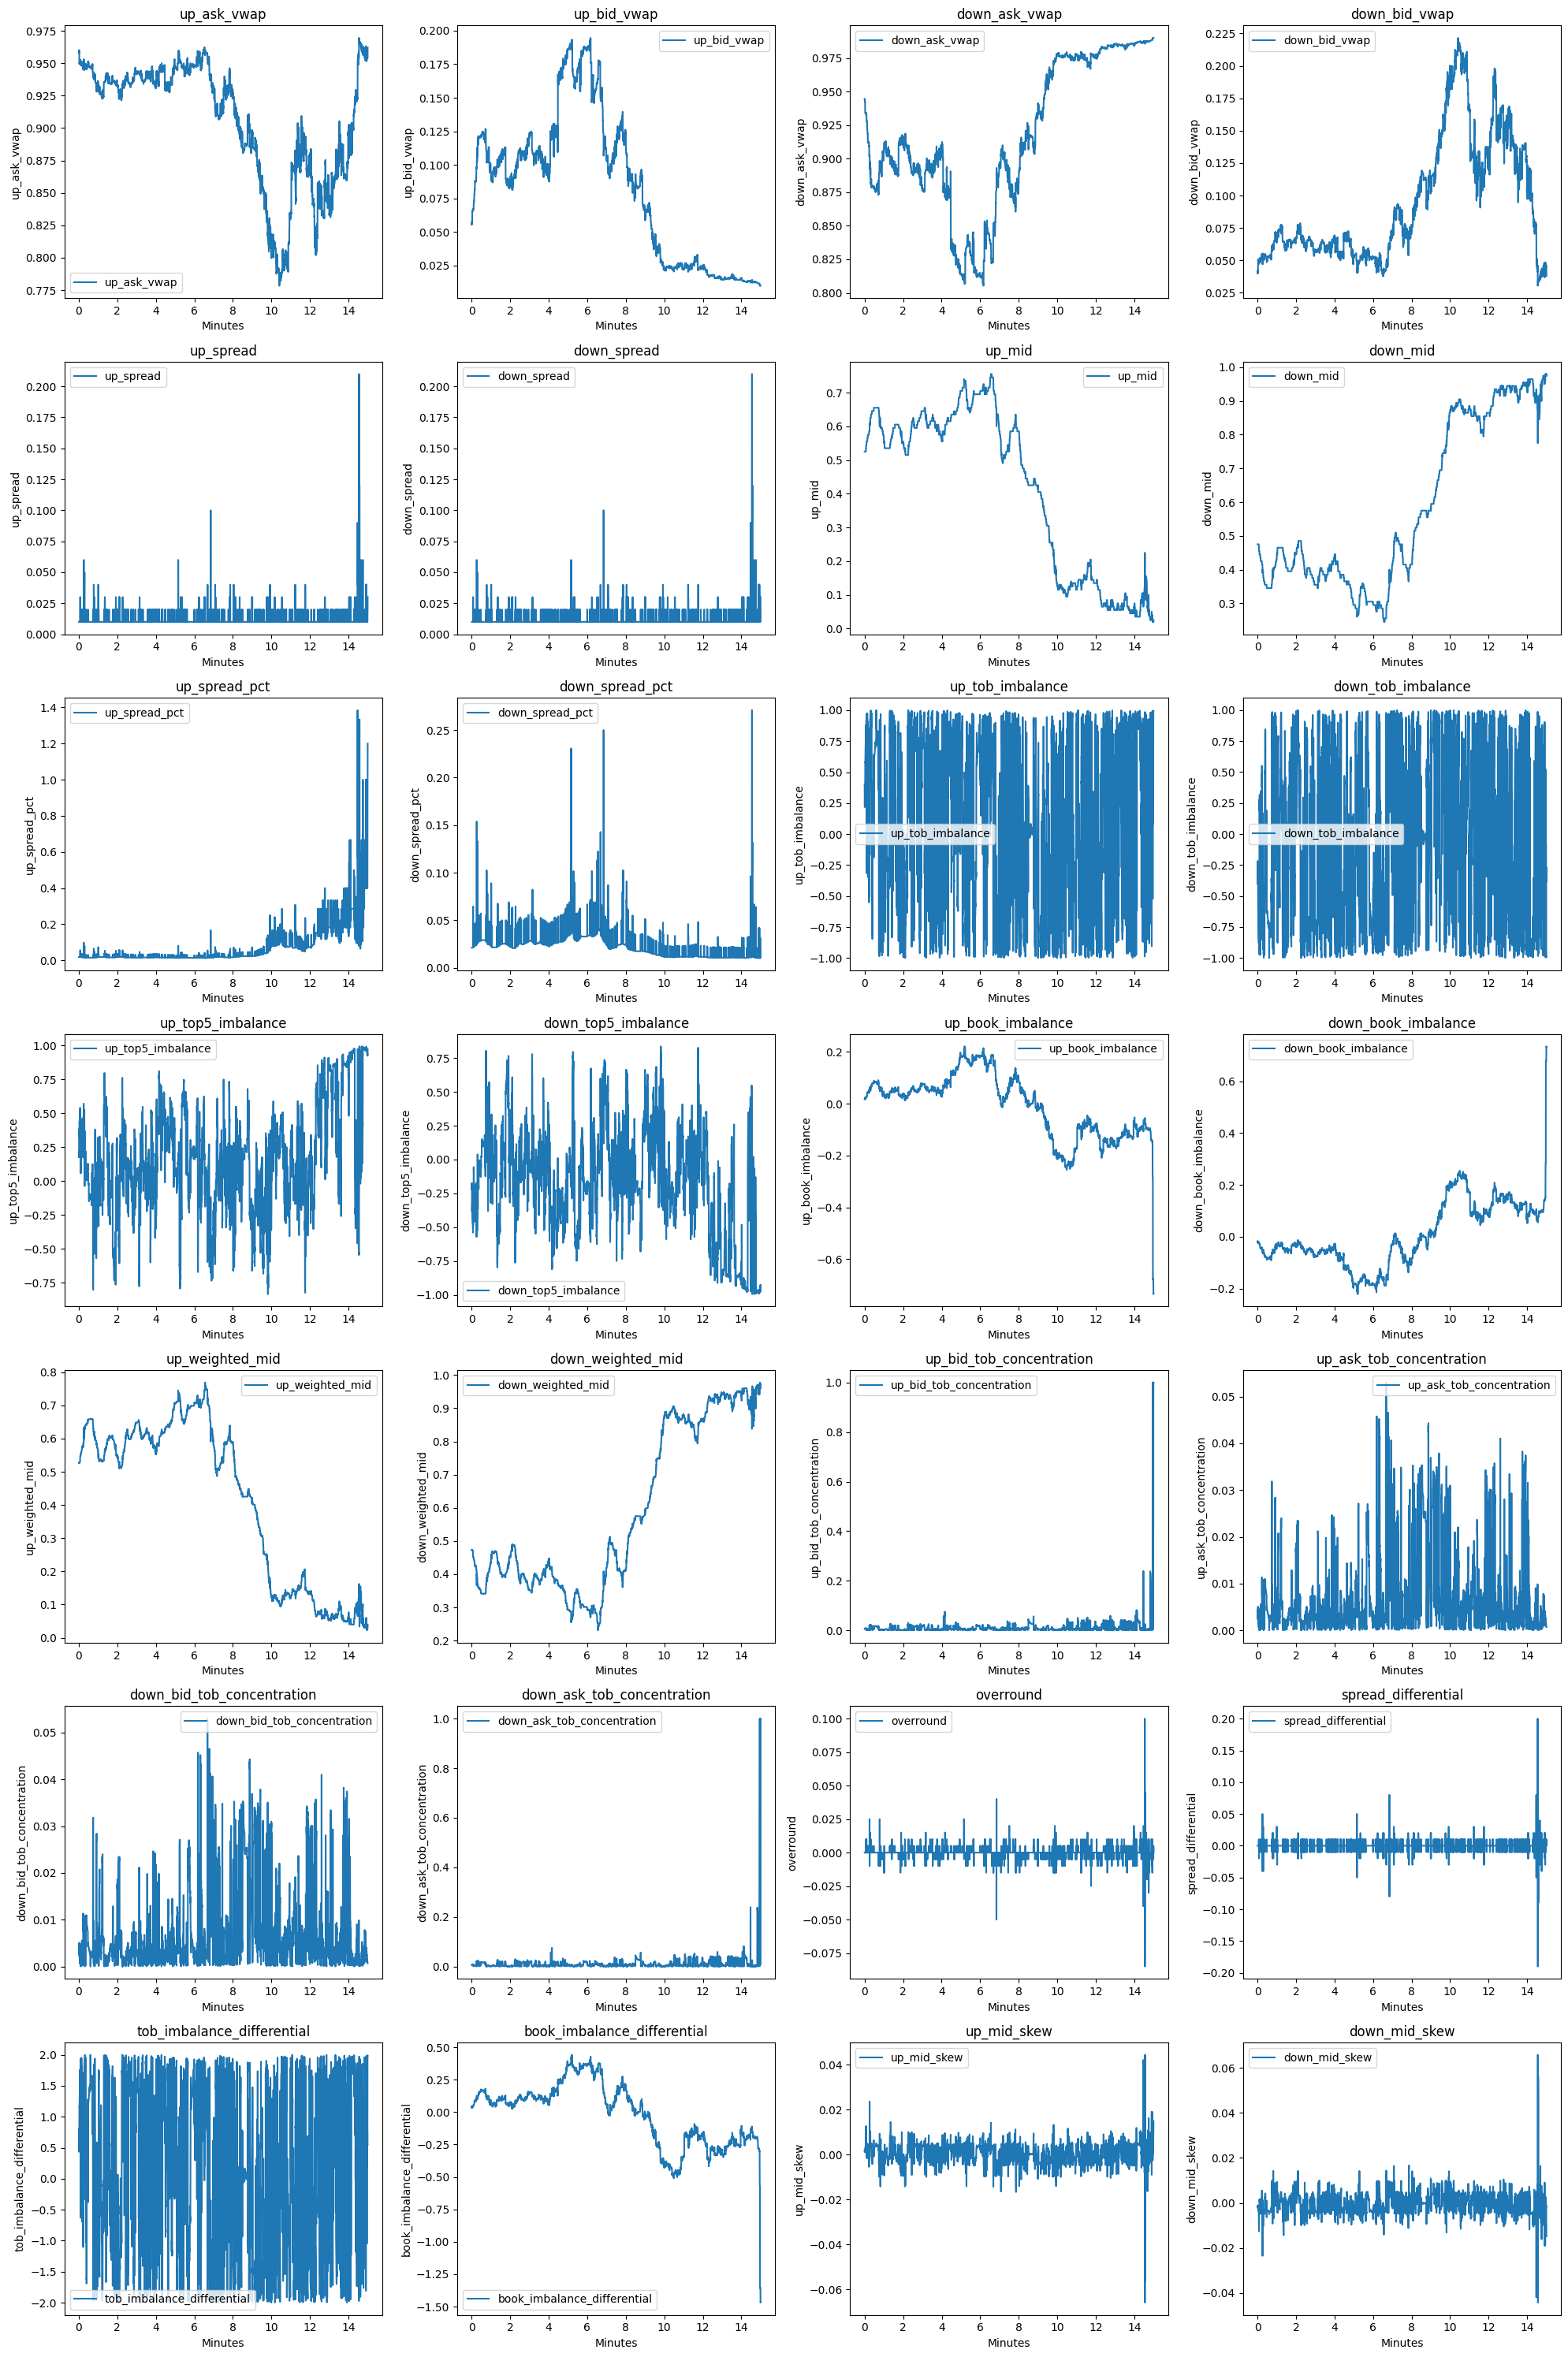

In [129]:
labels = [
    'up_ask_vwap',
    'up_bid_vwap',
    'down_ask_vwap',
    'down_bid_vwap',
    'up_spread',
    'down_spread',
    'up_mid',
    'down_mid',
    'up_spread_pct',
    'down_spread_pct',
    'up_tob_imbalance',
    'down_tob_imbalance',
    'up_top5_imbalance',
    'down_top5_imbalance',
    'up_book_imbalance',
    'down_book_imbalance',
    'up_weighted_mid',
    'down_weighted_mid',
    'up_bid_tob_concentration',
    'up_ask_tob_concentration',
    'down_bid_tob_concentration',
    'down_ask_tob_concentration',
    'overround',
    'spread_differential',
    'tob_imbalance_differential',
    'book_imbalance_differential',
    'up_mid_skew',
    'down_mid_skew'
]

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(20, 30))
axs = axs.flatten()

for i, label in enumerate(labels):
    x = np.linspace(0, 15, len(preprocessed_orderbook))
    axs[i].plot(x, preprocessed_orderbook[label], label=label)
    axs[i].set_title(label)
    axs[i].set_xlabel("Minutes")
    axs[i].set_ylabel(label)
    axs[i].legend()

plt.tight_layout()
plt.show()